# GRU Model for Battery RUL

This notebook starts from the shared window file created by preprocessing. The goal is to keep GRU-specific work separate from the shared data pipeline so GRU and GLU can be compared fairly.

In [1]:
# Import only the tools needed to locate and inspect the prepared window data.
# We do not import PyTorch yet because the first step is to confirm the data shape.
from pathlib import Path

import numpy as np

current_dir = Path.cwd().resolve()
if (current_dir / "data" / "processed" / "windows_w10.npz").exists():
    PROJECT_ROOT = current_dir
else:
    PROJECT_ROOT = current_dir.parent

WINDOW_FILE = PROJECT_ROOT / "data" / "processed" / "windows_w10.npz"

print("Project root:", PROJECT_ROOT)
print("Window file:", WINDOW_FILE)


Project root: C:\Users\PC\Battery-RUL-Prediction
Window file: C:\Users\PC\Battery-RUL-Prediction\data\processed\windows_w10.npz


In [2]:
# Load the prepared windows so the GRU uses the same split and features as the GLU model.
# X contains sequences of battery cycles, and y contains the RUL at the last cycle of each sequence.
data = np.load(WINDOW_FILE, allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

feature_columns = data["feature_columns"].tolist()
window_size = int(data["window_size"])

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Features:", feature_columns)
print("Window size:", window_size)


X_train: (318, 10, 7)
y_train: (318,)
X_val: (123, 10, 7)
y_val: (123,)
X_test: (159, 10, 7)
y_test: (159,)
Features: ['chI', 'chV', 'chT', 'disI', 'disV', 'BCt', 'SOH']
Window size: 10


In [3]:
# Validate the expected dimensions before model building.
# A GRU expects data shaped as samples, time steps, and features.
expected_feature_count = len(feature_columns)

assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3
assert y_train.ndim == 1
assert y_val.ndim == 1
assert y_test.ndim == 1

assert X_train.shape[1:] == (window_size, expected_feature_count)
assert X_val.shape[1:] == (window_size, expected_feature_count)
assert X_test.shape[1:] == (window_size, expected_feature_count)
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_test.shape[0] == y_test.shape[0]

print("Data shape validation passed.")
print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])


Data shape validation passed.
Train samples: 318
Validation samples: 123
Test samples: 159


In [4]:
# Convert NumPy arrays to PyTorch tensors because PyTorch models train on tensors.
# X keeps the sequence shape: samples, time steps, features.
# y is reshaped to samples, 1 so it matches the model output shape.
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)


X_train_tensor: torch.Size([318, 10, 7])
y_train_tensor: torch.Size([318, 1])
X_val_tensor: torch.Size([123, 10, 7])
y_val_tensor: torch.Size([123, 1])
X_test_tensor: torch.Size([159, 10, 7])
y_test_tensor: torch.Size([159, 1])


In [ ]:
# Wrap tensors in Dataset objects so each input sequence stays paired with its RUL label.
# DataLoaders feed the model small batches instead of sending the full dataset at once.
# Fixed seeds make model initialization and shuffled training batches reproducible across reruns.
import random
from torch.utils.data import TensorDataset, DataLoader

RANDOM_SEED = 42
BATCH_SIZE = 32

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_generator = torch.Generator()
train_generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


In [6]:
# Inspect one training batch to see exactly what the GRU will receive.
# batch_X goes into the model; batch_y is only used later to calculate the prediction error.
batch_X, batch_y = next(iter(train_loader))

print("batch_X shape:", batch_X.shape)
print("batch_y shape:", batch_y.shape)

print("One sequence shape:", batch_X[0].shape)
print("One target shape:", batch_y[0].shape)
print("First target value:", batch_y[0].item())


batch_X shape: torch.Size([32, 10, 7])
batch_y shape: torch.Size([32, 1])
One sequence shape: torch.Size([10, 7])
One target shape: torch.Size([1])
First target value: 56.0


In [ ]:
# Define a small GRU regression model.
# The GRU reads each 10-cycle window and the linear layer maps the final hidden state to one RUL prediction.
import torch.nn as nn

class GRURULModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_output, hidden = self.gru(x)
        final_hidden_state = hidden[-1]
        prediction = self.fc(final_hidden_state)
        return prediction


INPUT_SIZE = len(feature_columns)
HIDDEN_SIZE = 32
NUM_LAYERS = 1
OUTPUT_SIZE = 1

torch.manual_seed(RANDOM_SEED)

model = GRURULModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE,
)

print(model)


In [8]:
# Run one forward pass before training to confirm the model accepts a batch and returns one RUL prediction per window.
# This does not train the model yet; it only checks that the architecture and tensor shapes work together.
model.eval()

with torch.no_grad():
    sample_predictions = model(batch_X)

print("Input batch shape:", batch_X.shape)
print("Prediction shape:", sample_predictions.shape)
print("First 5 predictions before training:")
print(sample_predictions[:5].squeeze())

Input batch shape: torch.Size([32, 10, 7])
Prediction shape: torch.Size([32, 1])
First 5 predictions before training:
tensor([-0.0559, -0.0569, -0.0542, -0.0457, -0.0541])


In [9]:
# Define the loss function and optimizer.
# MSELoss measures prediction error for regression, and Adam updates model weights to reduce that error.
LOSS_FUNCTION = nn.MSELoss()
LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Loss function:", LOSS_FUNCTION)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [10]:
# Run one manual training step to see the full learning process before writing the training loop.
# This updates the model once using one batch.
model.train()

batch_X, batch_y = next(iter(train_loader))

optimizer.zero_grad()

predictions = model(batch_X)

loss = LOSS_FUNCTION(predictions, batch_y)

loss.backward()

optimizer.step()

print("Predictions shape:", predictions.shape)
print("Targets shape:", batch_y.shape)
print("Loss for this one batch:", loss.item())

Predictions shape: torch.Size([32, 1])
Targets shape: torch.Size([32, 1])
Loss for this one batch: 10644.263671875


In [11]:
# Train the model for multiple epochs and track both training and validation loss.
# Training loss shows how well the model fits B5/B7; validation loss checks generalization to B18.
EPOCHS = 100

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        predictions = model(batch_X)
        loss = LOSS_FUNCTION(predictions, batch_y)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(average_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = LOSS_FUNCTION(predictions, batch_y)

            total_val_loss += loss.item() * batch_X.size(0)

    average_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(average_val_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {average_train_loss:.2f} | "
            f"Validation Loss: {average_val_loss:.2f}"
        )

Epoch  10 | Train Loss: 7547.69 | Validation Loss: 4344.79
Epoch  20 | Train Loss: 6994.78 | Validation Loss: 3934.94
Epoch  30 | Train Loss: 6527.52 | Validation Loss: 3594.13
Epoch  40 | Train Loss: 6107.43 | Validation Loss: 3292.50
Epoch  50 | Train Loss: 5722.77 | Validation Loss: 3021.86
Epoch  60 | Train Loss: 5370.20 | Validation Loss: 2778.54
Epoch  70 | Train Loss: 5045.11 | Validation Loss: 2560.34
Epoch  80 | Train Loss: 4745.82 | Validation Loss: 2364.65
Epoch  90 | Train Loss: 4470.64 | Validation Loss: 2189.41
Epoch 100 | Train Loss: 4218.26 | Validation Loss: 2033.87


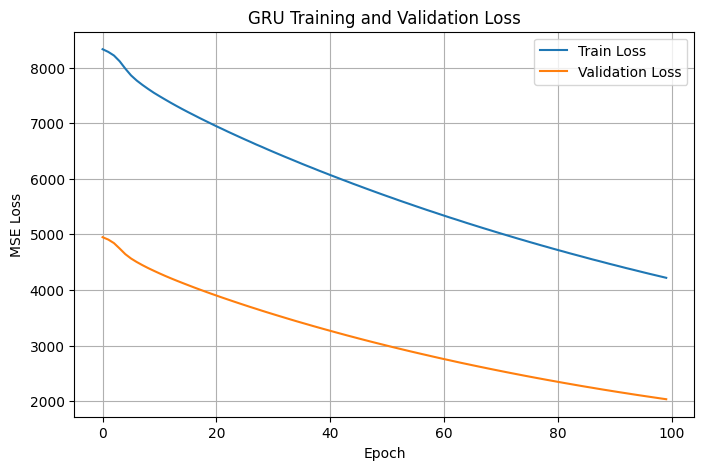

In [12]:
# Plot training and validation loss to see whether learning is still improving or starting to overfit.
# If both curves keep decreasing, the model is still learning; if validation rises while training falls, that suggests overfitting.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Train a fresh GRU model with early stopping.
# We keep the model version with the best validation loss, because the last epoch is not always the best one.
import copy

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

final_train_generator = torch.Generator()
final_train_generator.manual_seed(RANDOM_SEED)
final_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=final_train_generator,
)

model = GRURULModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE,
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

MAX_EPOCHS = 500
PATIENCE = 40

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in final_train_loader:
        optimizer.zero_grad()

        predictions = model(batch_X)
        loss = LOSS_FUNCTION(predictions, batch_y)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(average_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = LOSS_FUNCTION(predictions, batch_y)

            total_val_loss += loss.item() * batch_X.size(0)

    average_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(average_val_loss)

    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 25 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {average_train_loss:.2f} | "
            f"Validation Loss: {average_val_loss:.2f} | "
            f"Best Val: {best_val_loss:.2f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

model.load_state_dict(best_model_state)

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.2f}")

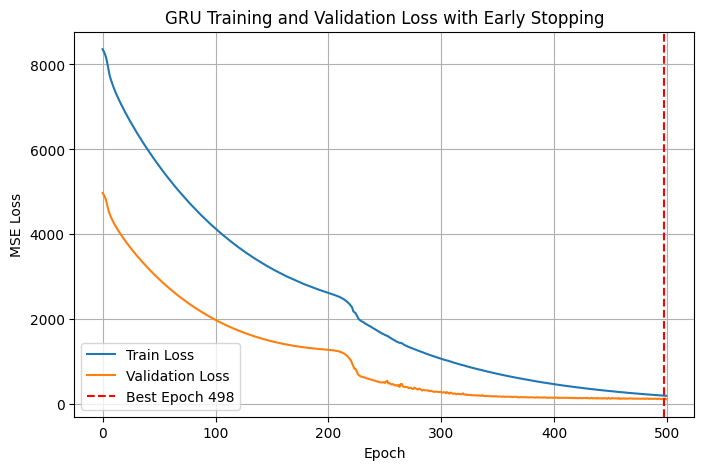

In [14]:
# Plot the early-stopping training history.
# This shows whether the model kept improving or started overfitting during the longer run.
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.axvline(best_epoch - 1, color="red", linestyle="--", label=f"Best Epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training and Validation Loss with Early Stopping")
plt.legend()
plt.grid(True)
plt.show()

## Final Test Evaluation on B6

The model has already been trained and selected using validation battery B18.

This section evaluates the best saved model on test battery B6 only once.  
B6 was not used for training, scaling decisions, early stopping, or model selection.

The goal is to estimate how well the GRU generalizes to a battery with a different degradation pattern.

In [15]:
# Evaluate the best model on the untouched test battery.
# Test data is used only now, after training decisions are finished.
model.eval()

test_predictions = []
test_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)

        test_predictions.append(predictions)
        test_targets.append(batch_y)

test_predictions = torch.cat(test_predictions).squeeze().numpy()
test_targets = torch.cat(test_targets).squeeze().numpy()

mae = np.mean(np.abs(test_predictions - test_targets))
rmse = np.sqrt(np.mean((test_predictions - test_targets) ** 2))

print(f"Test MAE: {mae:.2f} cycles")
print(f"Test RMSE: {rmse:.2f} cycles")

Test MAE: 41.97 cycles
Test RMSE: 44.01 cycles


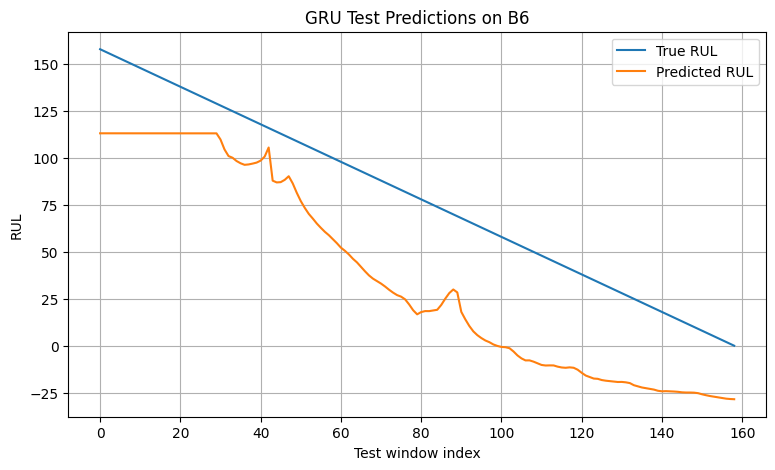

In [16]:
# Plot true and predicted RUL on the untouched test battery.
# This shows where the model succeeds or fails across the B6 life cycle.
plt.figure(figsize=(9, 5))
plt.plot(test_targets, label="True RUL")
plt.plot(test_predictions, label="Predicted RUL")
plt.xlabel("Test window index")
plt.ylabel("RUL")
plt.title("GRU Test Predictions on B6")
plt.legend()
plt.grid(True)
plt.show()

### Test Result Interpretation

The GRU performed much worse on the untouched test battery B6 than on the validation battery B18.

The final test metrics were:

- MAE: 41.97 cycles
- RMSE: 44.01 cycles

The plot shows that the model mostly underestimates RUL on B6. At the beginning, the true RUL is around 158 cycles, while the model predicts around 113 cycles. Later, the predicted RUL drops too quickly and even becomes negative, which is not physically valid for RUL.

This suggests that the model did not generalize well to B6. The likely reason is that the training batteries, B5 and B7, have similar slow-degradation behavior, while B6 has a different and faster degradation pattern. The model learned patterns that worked better for the validation battery B18, but these patterns did not transfer well to B6.

This result is valuable because it shows a real generalization problem rather than just a coding issue. For a more reliable evaluation, the next stage should include leave-one-battery-out cross-validation, where each battery is used once as the test battery.

In [ ]:
# Calculate validation and test metrics using the best model, so both splits are comparable.
# MAE and RMSE are measured in RUL cycles, which makes them easier to interpret than MSE.
import pandas as pd

model.eval()

val_predictions = []
val_targets = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        predictions = model(batch_X)

        val_predictions.append(predictions)
        val_targets.append(batch_y)

val_predictions = torch.cat(val_predictions).squeeze().numpy()
val_targets = torch.cat(val_targets).squeeze().numpy()

val_mae = np.mean(np.abs(val_predictions - val_targets))
val_rmse = np.sqrt(np.mean((val_predictions - val_targets) ** 2))

results_summary_df = pd.DataFrame(
    {
        "Split": ["Validation (B18)", "Test (B6)"],
        "MAE": [val_mae, mae],
        "RMSE": [val_rmse, rmse],
    }
)

results_summary_df
